In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

**Transfer learning**

In [2]:
# import section
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [4]:
# define the classes of the CIFAR-10 dataset
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# number of classes of the CIFAR-10 dataset
num_classes = len(labels)

**Data normalization**

In [5]:
# normalize the data for both x_train and x_test
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


**Prepare the labels**

In [6]:
# transform both y_train and y_test to categorical form
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


**Load the trained model**

In [7]:
#import os

#os.listdir()

# load the already trained model from file
base_model = keras.models.load_model("sample_data/cifar10.model17.keras")

# display the summary
base_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ random_translati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_4[0][0]  

 Total params: 3,031,072 (11.56 MB)

 Trainable params: 1,009,738 (3.85 MB)

 Non-trainable params: 1,856 (7.25 KB)

 Optimizer params: 2,019,478 (7.70 MB)

**Feature extractor: Freeze all layers of the loaded model**

In [8]:
# freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

**Create a new classifier, using as base the already trained model**

In [9]:
new_num_classes = 10

# extract the output layer before the last Dense
feature_output = base_model.get_layer("dropout_3").output

# add new layers (with unique names)
x = layers.Dense(128, activation='relu', name="transfer_dense_1")(feature_output)
x = layers.Dropout(0.3, name="transfer_dropout_1")(x)
new_output = layers.Dense(new_num_classes, activation='softmax', name="transfer_output")(x)

# build the new model
model_transfer = keras.Model(inputs=base_model.input, outputs=new_output)

# display the summary
model_transfer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ random_translati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_4[0][0]  

 Total params: 1,043,210 (3.98 MB)

 Trainable params: 34,186 (133.54 KB)

 Non-trainable params: 1,009,024 (3.85 MB)

**Compile the classifier**

In [10]:
model_transfer.compile(optimizer=keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

**Train the classifier**

In [11]:
# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# fit the model; measure the fit time
start = time.time()
#history = model_transfer.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=512, callbacks=[early_stop])
history = model_transfer.fit(x_train, y_train, validation_split=0.1, epochs=50, batch_size=512, callbacks=[early_stop])
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")

# display the average fit time per epoch
epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.5862 - loss: 1.2757 - val_accuracy: 0.8556 - val_loss: 0.4336
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8301 - loss: 0.5057 - val_accuracy: 0.8594 - val_loss: 0.4245
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8330 - loss: 0.5001 - val_accuracy: 0.8620 - val_loss: 0.4205
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8367 - loss: 0.4766 - val_accuracy: 0.8606 - val_loss: 0.4161
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8419 - loss: 0.4691 - val_accuracy: 0.8610 - val_loss: 0.4166
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8424 - loss: 0.4644 - val_accuracy: 0.8578 - val_loss: 0.4138
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8431 - loss: 0.4594 - val_accuracy: 0.8580 - val_loss: 0.4164
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8388 - loss: 0.4740 - val_accuracy: 0.8588 - 

**Fine tune the classifier: unfreeze some of the last layers, and train again**

In [12]:
for layer in base_model.layers[-20:]:
    # ultimele 20 straturi

    layer.trainable = True

model_transfer.compile(optimizer=keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# fit the model; measure the fit time
start = time.time()
history = model_transfer.fit(x_train, y_train, validation_split=0.1, epochs=50, batch_size=512, callbacks=[early_stop])
end = time.time()

# display the fit time
total_time = end - start
print("Training time:", total_time, "seconds")

# display the average fit time per epoch
epochs = len(history.history['loss'])
avg_time = total_time / epochs
print("Average time per epoch:", avg_time, "seconds")

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8493 - loss: 0.4456 - val_accuracy: 0.8668 - val_loss: 0.3908
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8540 - loss: 0.4296 - val_accuracy: 0.8698 - val_loss: 0.3932
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8606 - loss: 0.4181 - val_accuracy: 0.8708 - val_loss: 0.3936
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8639 - loss: 0.4006 - val_accuracy: 0.8722 - val_loss: 0.3932
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8612 - loss: 0.4095 - val_accuracy: 0.8744 - val_loss: 0.3920
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8592 - loss: 0.4118 - val_accuracy: 0.8744 - val_loss: 0.3894
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8646 - loss: 0.4043 - val_accuracy: 0.8752 - val_loss: 0.3879
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8644 - loss: 0.3997 - val_accuracy: 0.8744 - 

In [13]:
# display the accuracies for the train and validation sets
print(history.history.keys())

print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

# display the losses for the train and validation sets

print("Train loss:", history.history["loss"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8747555613517761
Validation accuracy: 0.8766000270843506
Train loss: 0.3703826069831848
Validation loss: 0.37444886565208435


**Evaluate the model**

Test accuracy: 0.8720999956130981
Test loss: 0.4068528413772583
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


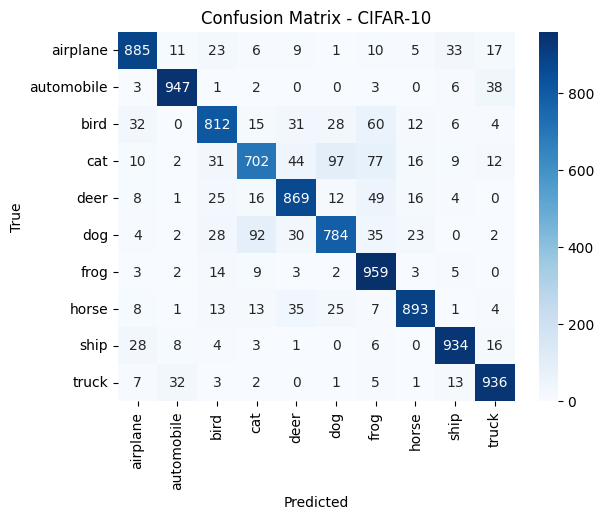

In [14]:
# evaluate the model and print the test accuracy and loss
score = model_transfer.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", score[1])
print("Test loss:", score[0])

# prepare and display the confusion matrix for the testing set
y_test_pred_prob = model_transfer.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(y_test.argmax(axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

**Save the model to file**

In [15]:
import os

#print("Working directory:", os.getcwd())
#print("Files here:", os.listdir())

# save the trained model
model_transfer.save("cifar10.model17_tl.keras")